In [1]:
import numpy as np
from qutip import wigner
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from functions import *
import math
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from plotting_lib.plotting import plot_marker_style
import matplotlib.ticker as ticker
from matplotlib.colors import TwoSlopeNorm

RUN_FOCK  = True # False
RUN_BINOM = True # False
RUN_CAT   = True # False
RUN_GKP   = True # False
recalc= True



/Users/adithi/anaconda3/lib/python3.10/site-packages/qutip-4.7.6-py3.10-macosx-11.0-arm64.egg/qutip/__init__.py:66: UserWarning: The new version of Cython, (>= 3.0.0) is not supported.
  warnings.warn(


In [2]:
N=9
n = 3     # number of photons in the initial state
T_1 = 500 # μs
kappa_mid = 1/T_1 # decay rate of the cavity (only for losses)
kappa=[kappa_mid*(9+i)/10 for i in range(3)]
t_max = 100 # μs (such that κt ~ 0.1)
nb_samples = 21
t_list = np.linspace(0,t_max,nb_samples)
  

In [99]:
########## FOCK STATE - number operator ############# 


In [4]:
# Here we create the noisy Fock states
rho_0 = qutip.fock_dm(N,n)
rho_list = create_states_diff_kappa(N, t_list, rho_0 = rho_0, kappa_list=kappa)

nb_F_samples = 20
eps_std = np.pi/4 * 5/100 # 5% of pi/4
initial_sin_angles = np.sqrt((1/2,1/2,1/3)) # exact values
noise_list = np.random.normal(0,eps_std,(nb_F_samples,3))

# to avoid recalculating everything when rerunning only some of the cells of the Notebook
if recalc:
    if RUN_FOCK or RUN_BINOM or RUN_CAT or RUN_GKP:
        
        F_list = [] # list of triplets of beam splitters
        for (i,noise) in enumerate(noise_list):
            if (i%1==0): print(f"{i+1}/{nb_F_samples}", end=" ")
            # Here we create the F3 gates with the noisy angles
            F_list.append(create_F3(N, initial_sin_angles, noise))
        recalc = False

1/20 (729, 729)
2/20 (729, 729)
3/20 (729, 729)
4/20 (729, 729)
5/20 (729, 729)
6/20 (729, 729)
7/20 (729, 729)
8/20 (729, 729)
9/20 (729, 729)
10/20 (729, 729)
11/20 (729, 729)
12/20 (729, 729)
13/20 (729, 729)
14/20 (729, 729)
15/20 (729, 729)
16/20 (729, 729)
17/20 (729, 729)
18/20 (729, 729)
19/20 (729, 729)
20/20 (729, 729)


In [9]:
if RUN_FOCK:
    uncoherent_t_loss = 10 # μs
    kappa_phi_mid = kappa_mid # dephasing rate
    result, result_loss, result_th = perform_protocol(N, rho_list, F_list,
                        # losses = None, # (A)
                        # losses="single", losses_gamma=losses_gamma, # (B)
                        losses="multiple", losses_gamma=[(kappa_mid*uncoherent_t_loss/3)*(9+i)/10 for i in range(3)], # (C)
                        dephasing = None, # (A)
                        # dephasing="single", dephasing_gamma=dephasing_gamma, # (B)
                        # dephasing="multiple", dephasing_gamma=[(kappa_phi_mid*uncoherent_t_loss/3)*(9+i)/10 for i in range(3)], # (C)
                        print_progression=True)
    result_th_3, result_th_4, result_withoutVD = result_th
print(np.shape(result))

1/21 2/21 3/21 4/21 5/21 6/21 7/21 8/21 9/21 10/21 11/21 12/21 13/21 14/21 15/21 16/21 17/21 18/21 19/21 20/21 21/21 (21, 20)


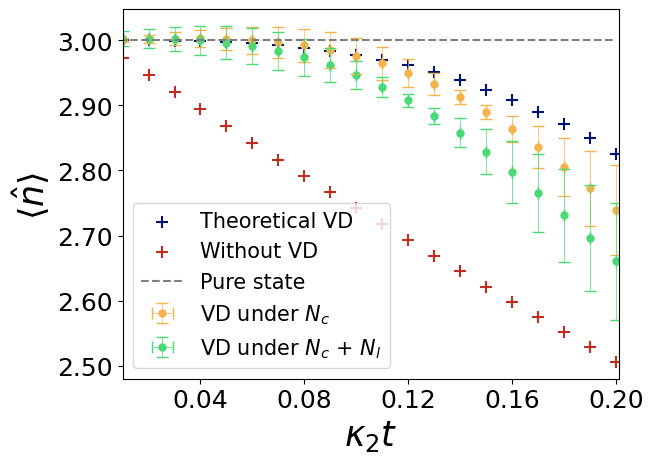

In [10]:
if RUN_FOCK:
    plots(kappa_mid*t_list, result, result_loss,
             [(result_th_3, "Theoretical VD "),
              (result_withoutVD, "Without VD"), 
              #(result_th_4, "Theoretical VD (4 copies)") # 4 copies
              ], ylabel="$\langle \hat{n} \\rangle$ ",remove_extreme=None, gamma_loss= True, legend= "lower left")

In [104]:
################### BINOMIAL STATE - number operator #############################

In [11]:
rho_binomial = qutip.ket2dm((qutip.fock(N,0) + qutip.fock(N,4)).unit())
noisy_binomial_list = create_states_diff_kappa(N, t_list, rho_binomial, kappa)


In [12]:
if RUN_BINOM:
    result_binomial, result_binomial_loss,result_binomial_th = perform_protocol(N, noisy_binomial_list,
                                                                        F_list, losses="multiple", losses_gamma=[(kappa_mid*uncoherent_t_loss/3)*(9+i)/10 for i in range(3)], dephasing=None, print_progression=True)

1/21 2/21 3/21 4/21 5/21 6/21 7/21 8/21 9/21 10/21 11/21 12/21 13/21 14/21 15/21 16/21 17/21 18/21 19/21 20/21 21/21 

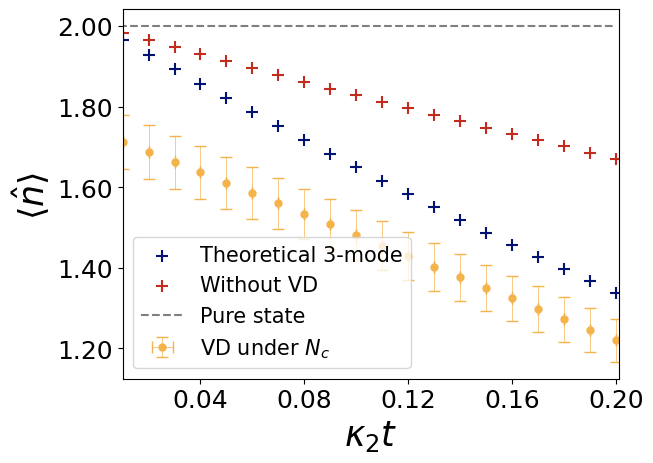

In [13]:
if RUN_BINOM:
    plots(kappa_mid*t_list, result_binomial, result_binomial_loss,
             [(result_binomial_th[0], "Theoretical 3-mode"),
              (result_binomial_th[2],"Without VD"),
           # (result_binomial_th[1], "Theoretical 4-mode")
           ], ylabel="$\langle \hat{n} \\rangle$ ", gamma_loss=None, legend='lower left')



In [15]:
alpha = 1.0
rho_cat = qutip.ket2dm((qutip.coherent(N, alpha) + qutip.coherent(N, -alpha)).unit())
nb_samples_cat = 20 # less samples to avoid too long computation
noisy_cat_list = create_states_diff_kappa(N, t_list, rho_cat, kappa)
if RUN_CAT:
    result_cat, result_cat_loss, result_cat_th = perform_protocol(N, noisy_cat_list, 
                                        F_list[:nb_samples_cat], losses=None, print_progression=True)




1/21 2/21 3/21 4/21 5/21 6/21 7/21 8/21 9/21 10/21 11/21 12/21 13/21 14/21 15/21 16/21 17/21 18/21 19/21 20/21 21/21 

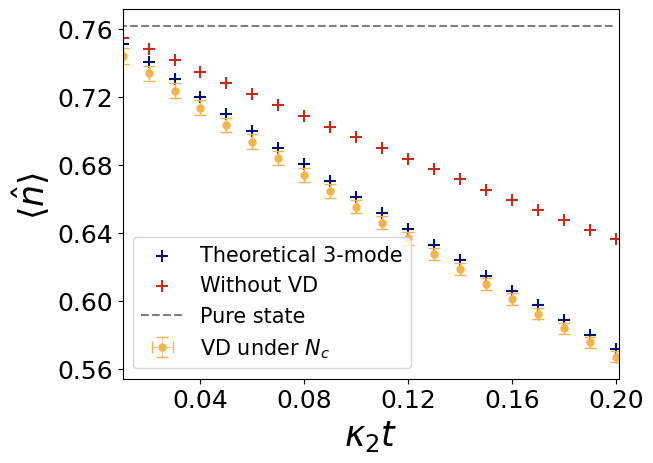

In [8]:
if RUN_CAT:
    plots(kappa_mid*t_list, result_cat, result_cat_loss,
             [(result_cat_th[0], "Theoretical 3-mode"),
              (result_cat_th[2],"Without VD"),
           # (result_binomial_th[1], "Theoretical 4-mode")
           ], ylabel="$\langle \hat{n} \\rangle$ ", gamma_loss=None, legend='lower left')



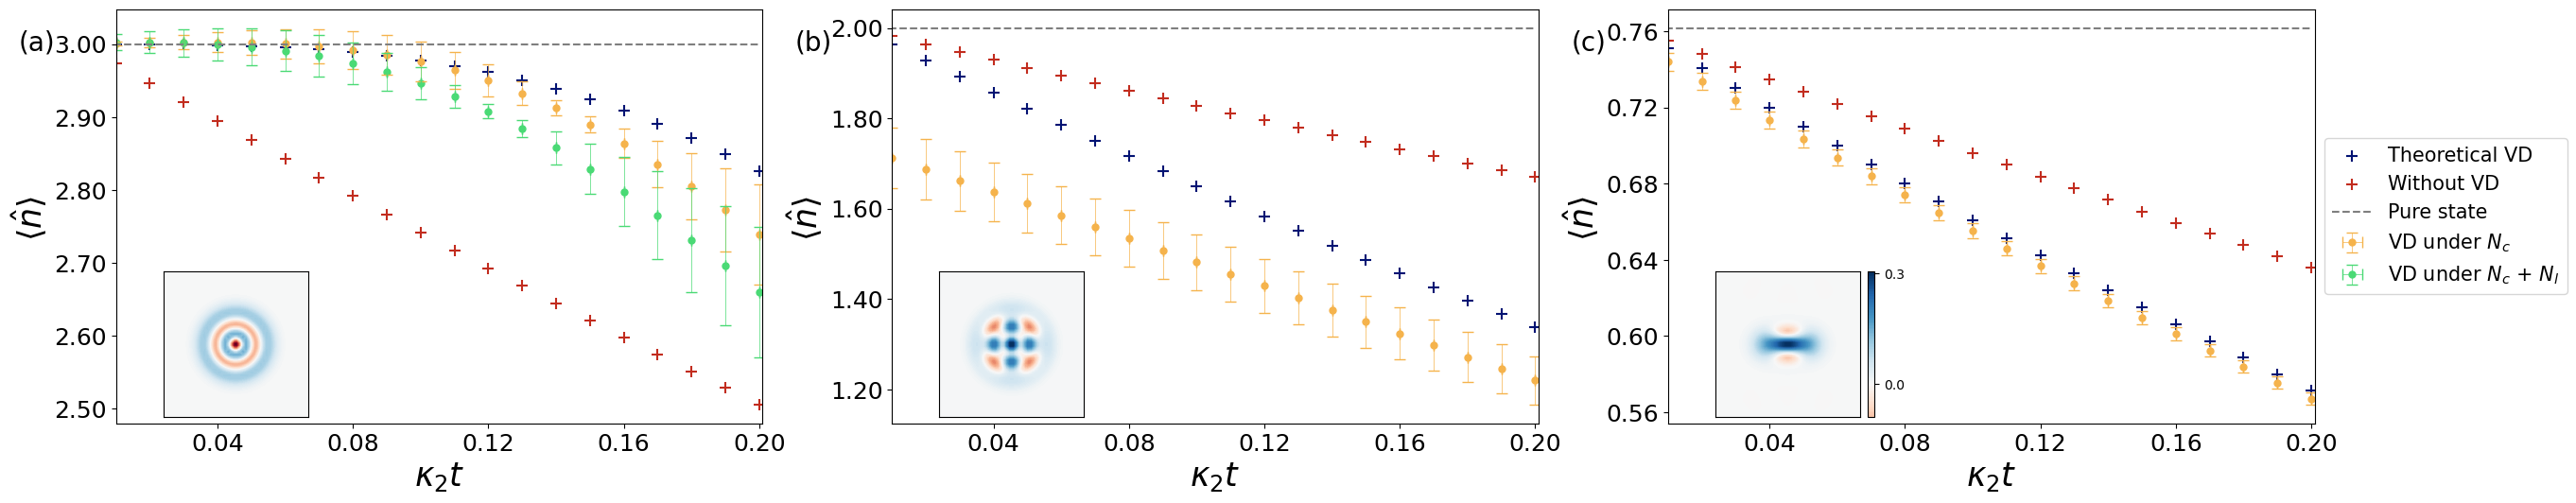

In [16]:
nb_samples = 21
t_list = np.linspace(0,t_max,nb_samples)
fig, axs = plt.subplots(1, 3, figsize=(30, 6))
plt.sca(axs[0])
plots(kappa_mid*t_list, result, result_loss,
             [(result_th_3, "Theoretical VD "),
              (result_withoutVD, "Without VD"), 
              #(result_th_4, "Theoretical VD (4 copies)") # 4 copies
              ], ylabel="$\langle \hat{n} \\rangle$ ",remove_extreme=None, gamma_loss= True, legend="lower center", box= (3.4, 0.5))

plt.sca(axs[1])

plots(kappa_mid*t_list, result_binomial, result_binomial_loss,
             [(result_binomial_th[0], "Theoretical 3-mode"),
              (result_binomial_th[2],"Without VD"),
           # (result_binomial_th[1], "Theoretical 4-mode")
           ], ylabel="$\langle \hat{n} \\rangle$ ", gamma_loss=None)
plt.sca(axs[2])
plots(kappa_mid*t_list, result_cat, result_cat_loss,
            [(result_cat_th[0], "Theoretical 3-mode"),
            (result_cat_th[2],"Without VD"),
        # (result_binomial_th[1], "Theoretical 4-mode")
        ], ylabel="$\langle \hat{n} \\rangle$ ", gamma_loss=None)

bound = 5
xvec = np.linspace(-bound, bound, 50)
yvec = np.linspace(-bound, bound, 50)



states_list= [rho_0, rho_binomial, rho_cat] 
labels = ['(a)', '(b)', '(c)']

for i, ax in enumerate(axs):
    ax.text(
        -0.15, 0.95, labels[i],   # position (in axes coordinates)
        transform=ax.transAxes,
        fontsize=20,
        verticalalignment='top'
    )
    
    # Create inset
    axins = inset_axes(ax,width="35%", height="35%",loc="lower left")  # [x, y, width, height] in axes fraction
    axins.set_aspect('equal', adjustable='box')
    W = wigner(states_list[i], xvec, yvec)

    vmax = abs(W).max()
    vmin = -vmax
    ticks = np.round([0, vmax],2)

    im = axins.contourf(xvec, yvec, W,100,cmap='RdBu',vmin=vmin,vmax=vmax)
    if i==2:
        cax = inset_axes(axins,width="5%", height="100%",loc="lower left",bbox_to_anchor=(1.05, 0, 1, 1),bbox_transform=axins.transAxes,borderpad=0)
        cb= plt.colorbar(im, cax= cax)
        cb.set_ticks(ticks)
    axins.set_xlim(-bound, bound)
    axins.set_ylim(-bound, bound)

    # Optional: remove ticks for cleaner look
    axins.set_xticks([])
    axins.set_yticks([])
plt.subplots_adjust(bottom=0.15)  #it gets cut at the bottom while saving
plt.savefig('/Users/adithi/Documents/Work/Leonardo_project/plots/number_op.pdf')

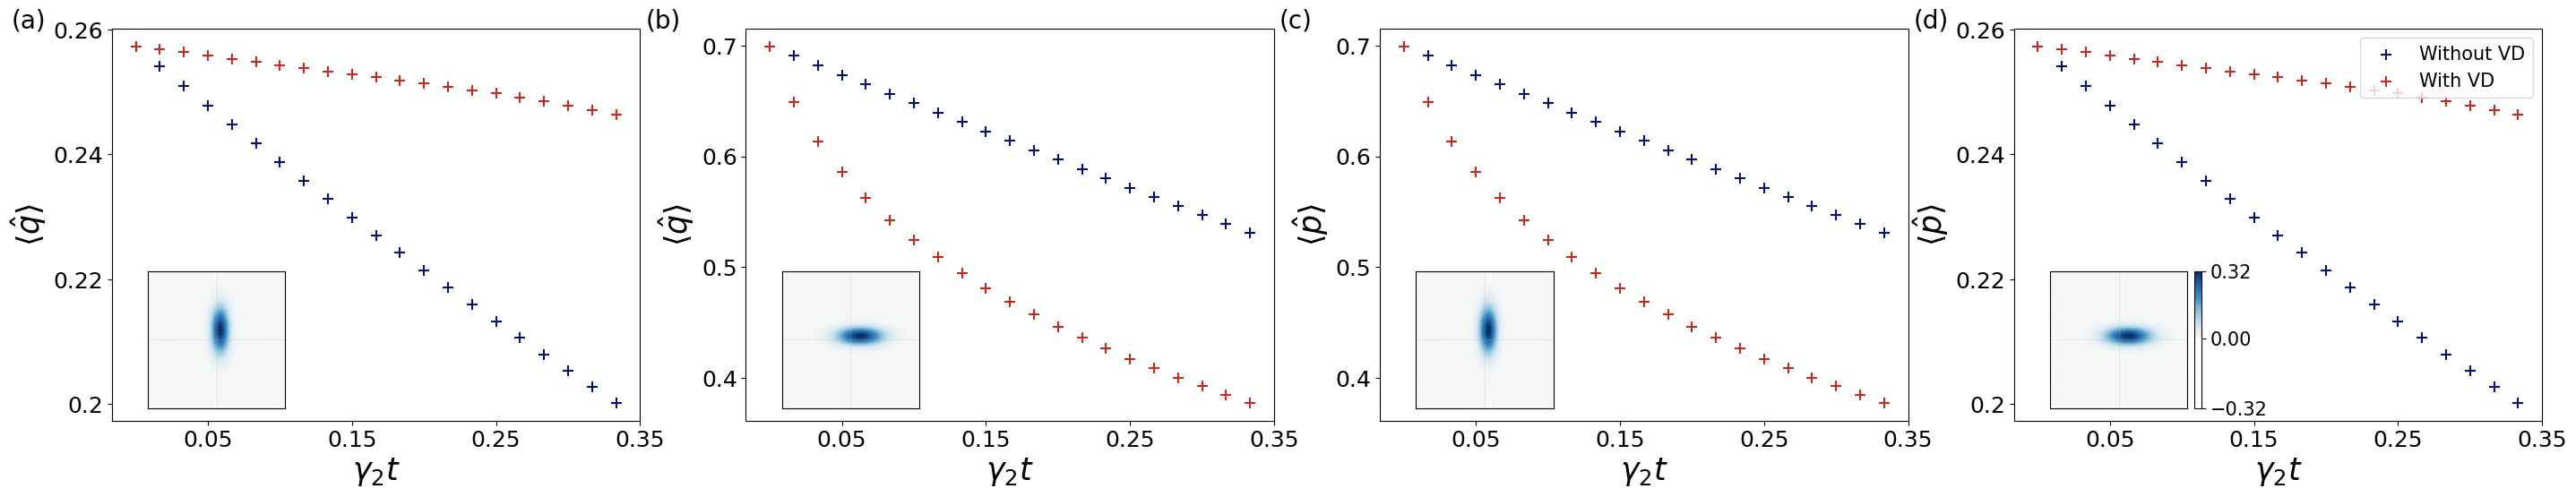

In [17]:

N=30
nb_samples = 21
t_list = np.linspace(0, 500, nb_samples)
alpha = 0.3 + 0.3j
uncoherent_t_loss = 5 
T_1= 500
kappa_mid= 1/T_1
kappa_phi_mid= kappa_mid/3


rho_list= [(qutip.ket2dm(qutip.squeeze(N, 0.5)*qutip.coherent(N, alpha))), (qutip.ket2dm(qutip.squeeze(N, -0.5)*qutip.coherent(N, alpha)))]
#first is squeezed with 0.5 in q and second is squeezed with -0.5 along p 

rho_dephased_list = [create_states_dephasing_diff_kappa_phi(N, t_list, rho, [(kappa_phi_mid*uncoherent_t_loss/3)*(9+i)/10 for i in range(3)]) for rho in rho_list]
  
operator_p = (qutip.destroy(N) - qutip.create(N)) / (1j * np.sqrt(2))
operator_q = (qutip.destroy(N) + qutip.create(N)) / np.sqrt(2)


f, ax = plt.subplots(1, 4, figsize=(35, 6))

bound = 5
xvec = np.linspace(-bound, bound, 50)
yvec = np.linspace(-bound, bound, 50)

# --- configs for main plots ---
configs = [
    (operator_q, rho_dephased_list[0], "$\\langle \\hat{q} \\rangle$",[0.20, 0.22, 0.24, 0.26]),
    ( operator_q, rho_dephased_list[1], "$\\langle \\hat{q} \\rangle$", [0.4, 0.5, 0.6, 0.7]),
    ( operator_p, rho_dephased_list[0], "$\\langle \\hat{p} \\rangle$",[0.4, 0.5, 0.6, 0.7]),
    (operator_p, rho_dephased_list[1], "$\\langle \\hat{p} \\rangle$",[0.20, 0.22, 0.24, 0.26]),
]

inset_rhos = [rho_list[0], rho_list[1], rho_list[0], rho_list[1]]
axes_labels = ["(a)", "(b)", "(c)", "(d)"]
insets = []
Ws = []

for i, ( op, rhos, ylabel, ytickl) in enumerate(configs):
    ax[i].scatter(
        kappa_phi_mid*t_list,
        [qutip.expect(op, rho) for rho in rhos],
        label="Without VD", color= "#021373", marker='+',s= 70
    )
    ax[i].scatter(
         kappa_phi_mid*t_list,
        [qutip.expect(op, rho**3)/(rho**3).tr() for rho in rhos],
        label="With VD", c="#C22C1E", marker='+', s= 70
    )

    ax[i].set_xlabel("$\gamma_2 t$", fontsize=25)
    ax[i].set_ylabel(ylabel, fontsize= 25)
    
    if i==3:
        ax[i].legend(loc="upper right",fontsize=15)

    ax[i].text(-0.19, 1.05, axes_labels[i],
               transform=ax[i].transAxes,
               fontsize=20, va="top")

    # inset
    axins = inset_axes(ax[i], width="35%", height="35%",
                       loc="lower left", borderpad=1)
    W = wigner(inset_rhos[i], xvec, yvec)

    insets.append(axins)
    Ws.append(W)
    xticks=[0.05, 0.15, 0.25, 0.35]
    ax[i].set_xticks(xticks)
    ax[i].set_xticklabels(xticks, fontsize=18)
    yticks= ytickl
    ax[i].set_yticks(yticks)
    ax[i].set_yticklabels(yticks, fontsize=18)

vmax = max(abs(Ws[0]).max(), abs(Ws[1]).max(),
           abs(Ws[2]).max(), abs(Ws[3]).max())
vmin = -vmax
ticks = np.round([vmin, 0, vmax], 2)

for i, axins in enumerate(insets):
    axins.set_aspect('equal')
    im = axins.contourf(xvec, yvec, Ws[i], 100,
                        cmap='RdBu', vmin=vmin, vmax=vmax)
    axins.set_xticks([-5, 0, 5])
    axins.set_yticks([-5, 0, 5])
    axins.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

    axins.tick_params(
        axis='both',
        which='both',
        bottom=False, top=False,
        left=False, right=False,
        labelbottom=False, labelleft=False
    )

    if i==3:
        cax = inset_axes(
        axins,
        width="5%", height="100%",
        loc="lower left",
        bbox_to_anchor=(1.05, 0, 1, 1),
        bbox_transform=axins.transAxes,
        borderpad=0)
    
        cb = plt.colorbar(im, cax=cax)
        cb.set_ticks(ticks)
        cb.ax.tick_params(labelsize=15)

plt.subplots_adjust(bottom=0.15)
plt.savefig('/Users/adithi/Documents/Work/Leonardo_project/plots/quadrature.pdf')
